In [57]:
import pandas as pd
#from category_encoders import TargetEncoder # encodeur erreur en prod à cause de compatibilité streamlit
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


In [59]:
data = pd.read_csv("housing.csv")

In [60]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [62]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [63]:
data.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [65]:
data["rooms_per_household"] = data["total_rooms"] / data["households"]

data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]

data["population_per_household"] = data["population"] / data["households"]

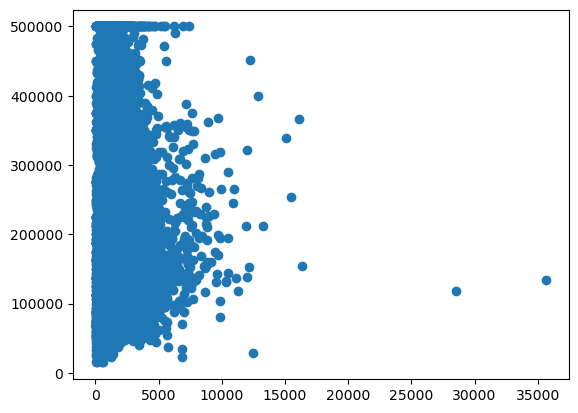

In [68]:
plt.scatter(data["population"],data["median_house_value"])

# Nettoyage

In [71]:
#supprimer les lignes à info vide de total_bedrooms
data = data.dropna(subset=["total_bedrooms"])

#convertir certaines colonnes flottantes en entier

cols_to_int = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]
data[cols_to_int] = data[cols_to_int].astype(float).round().astype("int64")
data.dtypes

longitude                   float64
latitude                    float64
housing_median_age          float64
total_rooms                   int64
total_bedrooms                int64
population                    int64
households                    int64
median_income               float64
median_house_value          float64
ocean_proximity              object
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

### suppression des outlier (tronquage des valeurs extrèmes)

In [74]:
cols = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]
for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

In [77]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20433.000000,20433.000000,20433.000000,20433.00000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2440.46557,502.538076,1335.894240,468.742426,3.801660,206864.413155,5.431344,0.213039,3.071533
std,2.003578,2.136348,12.591805,1394.61925,287.085265,763.964234,264.981678,1.657657,115435.667099,2.482946,0.057983,10.438269
min,-124.350000,32.540000,1.000000,2.00000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.800000,33.930000,18.000000,1450.00000,296.000000,787.000000,280.000000,2.563700,119500.000000,4.441441,0.175427,2.429032
50%,-118.490000,34.260000,29.000000,2127.00000,435.000000,1166.000000,409.000000,3.536500,179700.000000,5.230769,0.203162,2.817582
75%,-118.010000,37.720000,37.000000,3143.00000,647.000000,1722.000000,604.000000,4.744000,264700.000000,6.052381,0.239821,3.281513
max,-114.310000,41.950000,52.000000,5682.50000,1173.500000,3124.500000,1090.000000,8.014450,500001.000000,141.909091,1.000000,1243.333333


### Division en X_train Xtest et encodage

In [92]:
#encoder la variable non numérique
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]
#encodage
encoded = encoder.fit_transform(X[["ocean_proximity"]])
encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out()) #mets les nom des colonnes en string
#l'encodage avec One hot transform en numpy 
#suppression de la colonne originale
X = X.drop("ocean_proximity", axis=1)
#retransformation concatenation et retransformation d'encoded dataframe
X_enc = pd.concat([X.reset_index(drop=True), pd.DataFrame(encoded)], axis=1)

# Algorithme de ML

In [95]:
#division du dataset en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

## Suppot vector Regression SVR 

In [98]:
model = SVR(kernel="rbf", C=100, gamma="scale")

In [100]:
model.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [102]:
from sklearn.metrics import mean_squared_error

#print("mean_squared_error: ",model.mean_squared_error(X_test_scaled, y_test))
print("r2_error: ",model.score(X_test_scaled, y_test))

r2_error:  0.32952968674949845


In [103]:
model = SVR(
    kernel="rbf",
    C=1000,
    gamma=0.1,
    epsilon=0.1
)

In [104]:
model.fit(X_train_scaled, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [105]:
from sklearn.metrics import mean_squared_error

#print("mean_squared_error: ",model.mean_squared_error(X_test_scaled, y_test))
print("r2_error: ",model.score(X_test_scaled, y_test))

r2_error:  0.6029209295227804


In [106]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
#print("mean_squared_error: ",model.mean_squared_error(X_test_scaled, y_test))
print("r2: ",model.score(X_test_scaled, y_test))
y_pred=model.predict(X_test_scaled)
print("MAE: ",mean_absolute_error( y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2:  0.6029209295227804
MAE:  50007.8157435557
MSE:  5430128075.132149
RMSE: 73689.4027329042


In [107]:
#Calcul des meilleurs parametres du SVR pour C
R2=[]
MAE=[]
MSE=[]
RMSE=[]

Valeurs_C = [100, 300, 500, 1000, 1500, 2000,2300,3000,3500,3900,4200,4500,5000,5200,5500,6000,6200,6500,7000,7200,7500,8000,8200,8300,8400,8700,9000]
for i in Valeurs_C :
    model = SVR(
    kernel="rbf",
    C=i,
    gamma=0.125,
    epsilon=0.1
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    R2.append(model.score(X_test_scaled, y_test))
    print("R2: ",R2)
    MAE.append(mean_absolute_error( y_test,y_pred))
    print("MAE: ",MAE)
    MSE.append(mean_squared_error( y_test,y_pred))
    print("MSE: ",MSE)
    RMSE.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    print("RMSE: ",RMSE)
print("R2: ",R2)
print("MAE: ",MAE)
print("MSE: ",MSE)
print("RMSE: ",RMSE)

R2:  [0.2623593811260817]
MAE:  [69433.04505605796]
MSE:  [10087368818.233675]
RMSE:  [100435.8940729542]
R2:  [0.2623593811260817, 0.43032637950857633]
MAE:  [69433.04505605796, 59885.28114068231]
MSE:  [10087368818.233675, 7790389749.263113]
RMSE:  [100435.8940729542, 88263.18456334506]
R2:  [0.2623593811260817, 0.43032637950857633, 0.5014716963504164]
MAE:  [69433.04505605796, 59885.28114068231, 55871.63458533901]
MSE:  [10087368818.233675, 7790389749.263113, 6817464679.3702345]
RMSE:  [100435.8940729542, 88263.18456334506, 82567.9397791312]
R2:  [0.2623593811260817, 0.43032637950857633, 0.5014716963504164, 0.5857714942453733]
MAE:  [69433.04505605796, 59885.28114068231, 55871.63458533901, 50929.53649915361]
MSE:  [10087368818.233675, 7790389749.263113, 6817464679.3702345, 5664649702.929331]
RMSE:  [100435.8940729542, 88263.18456334506, 82567.9397791312, 75263.86718027004]
R2:  [0.2623593811260817, 0.43032637950857633, 0.5014716963504164, 0.5857714942453733, 0.6288264805756006]
MAE:

# figure

## R2 en fonction de C

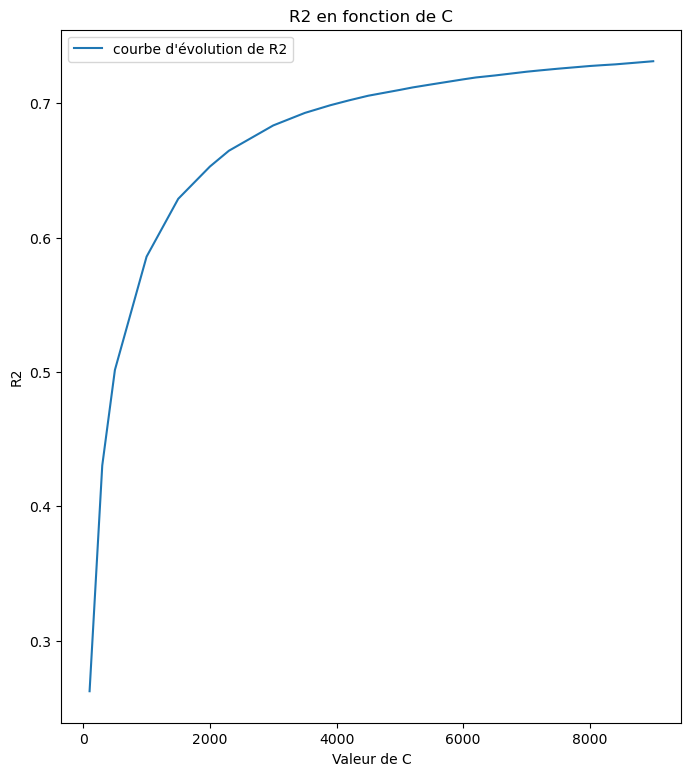

In [110]:
plt.figure(figsize=(8,9))
plt.title("R2 en fonction de C")
plt.plot(Valeurs_C,R2,label="courbe d'évolution de R2")

plt.xlabel("Valeur de C")
plt.ylabel("R2")
plt.legend()
plt.show()

## MAE en fonction de C

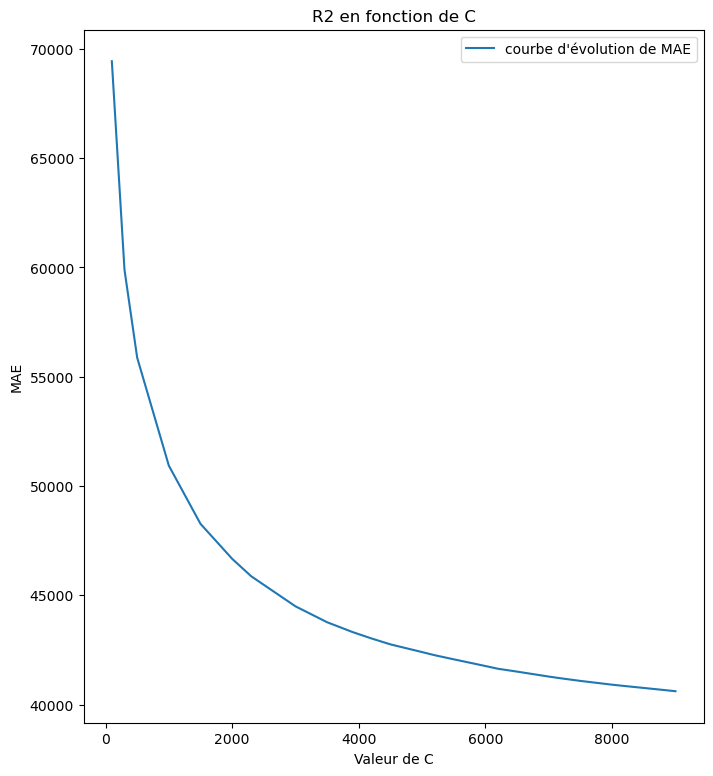

In [112]:
plt.figure(figsize=(8,9))
plt.title("R2 en fonction de C")
plt.plot(Valeurs_C,MAE,label="courbe d'évolution de MAE")

plt.xlabel("Valeur de C")
plt.ylabel("MAE")
plt.legend()
plt.show()

## MSE en fonction de C

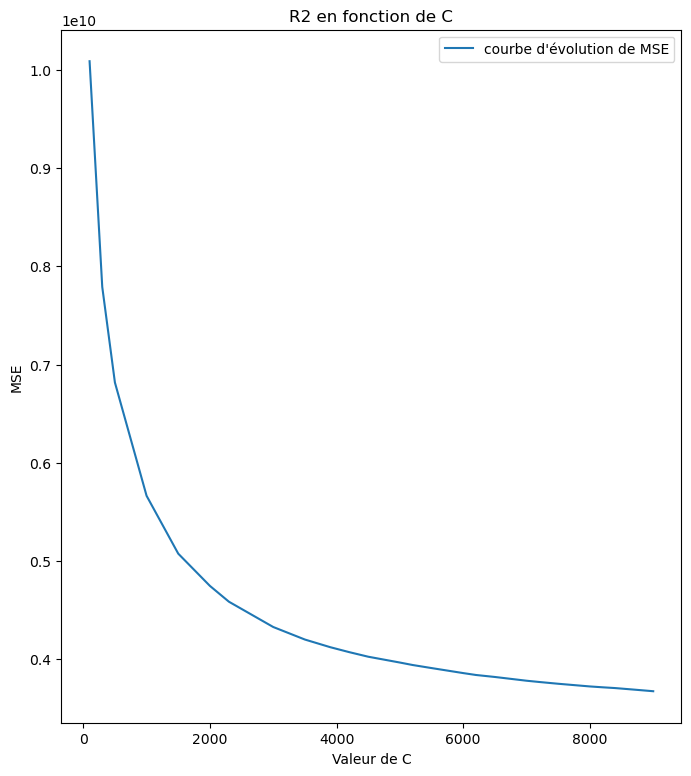

In [114]:
plt.figure(figsize=(8,9))
plt.title("R2 en fonction de C")
plt.plot(Valeurs_C,MSE,label="courbe d'évolution de MSE")
plt.xlabel("Valeur de C")
plt.ylabel("MSE")
plt.legend()
plt.show()

## RMSE en fonction de C

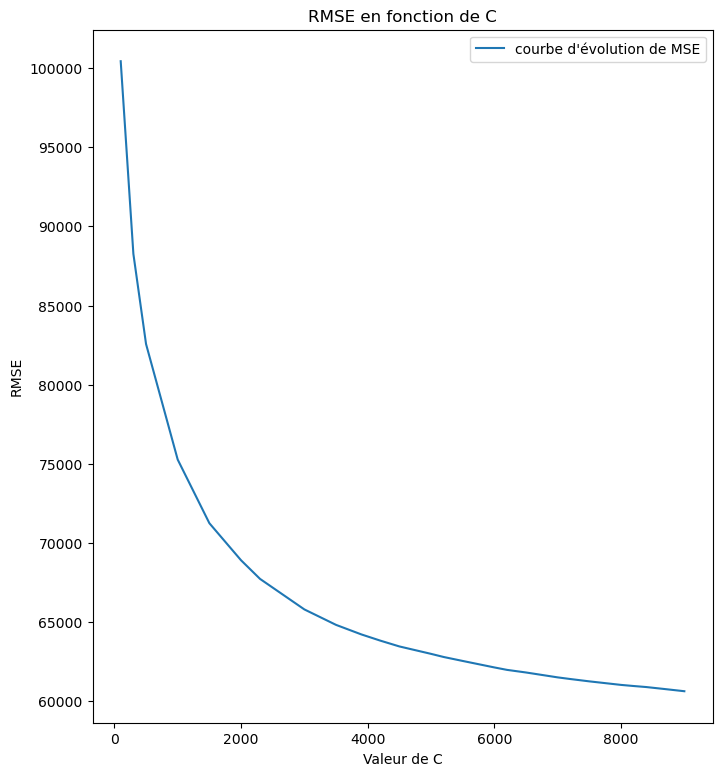

In [116]:
plt.figure(figsize=(8,9))
plt.title("RMSE en fonction de C")
plt.plot(Valeurs_C,RMSE,label="courbe d'évolution de MSE")
plt.legend()
plt.xlabel("Valeur de C")
plt.ylabel("RMSE")
plt.show()

## Chargement du meilleur Modèle

In [120]:
model = SVR(
    kernel="rbf",
    C=9000,
    gamma=0.125,
    epsilon=0.1
    )
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [121]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [122]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [123]:
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

In [ ]:
#chargement
#scaler = joblib.load("scaler.pkl")
#model = joblib.load("model.pkl")
#encoder=joblib.load("encoder.pkl")